In [1]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 
import warnings
warnings.filterwarnings('ignore')

In [3]:
df =pd.read_csv(r"C:\Users\DELL\Downloads\Student_performance_data.csv")

In [5]:
df.head()

,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
0,1001,17,1,0,2,19.833723,7,1,2,0,0,1,0,2.929196,2.0
1,1002,18,0,0,1,15.408756,0,0,1,0,0,0,0,3.042915,1.0
2,1003,15,0,2,3,4.210570,26,0,2,0,0,0,0,0.112602,4.0
3,1004,17,1,0,3,10.028829,14,0,3,1,0,0,0,2.054218,3.0
4,1005,17,1,0,2,4.672495,17,1,3,0,0,0,0,1.288061,4.0


In [7]:
df.shape

(2392, 15)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2392 entries, 0 to 2391
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   StudentID          2392 non-null   int64  
 1   Age                2392 non-null   int64  
 2   Gender             2392 non-null   int64  
 3   Ethnicity          2392 non-null   int64  
 4   ParentalEducation  2392 non-null   int64  
 5   StudyTimeWeekly    2392 non-null   float64
 6   Absences           2392 non-null   int64  
 7   Tutoring           2392 non-null   int64  
 8   ParentalSupport    2392 non-null   int64  
 9   Extracurricular    2392 non-null   int64  
 10  Sports             2392 non-null   int64  
 11  Music              2392 non-null   int64  
 12  Volunteering       2392 non-null   int64  
 13  GPA                2392 non-null   float64
 14  GradeClass         2392 non-null   float64
dtypes: float64(3), int64(12)
memory usage: 280.4 KB


In [11]:
df.isnull().sum()

StudentID            0
Age                  0
Gender               0
Ethnicity            0
ParentalEducation    0
StudyTimeWeekly      0
Absences             0
Tutoring             0
ParentalSupport      0
Extracurricular      0
Sports               0
Music                0
Volunteering         0
GPA                  0
GradeClass           0
dtype: int64

In [13]:
df.duplicated().sum()

0

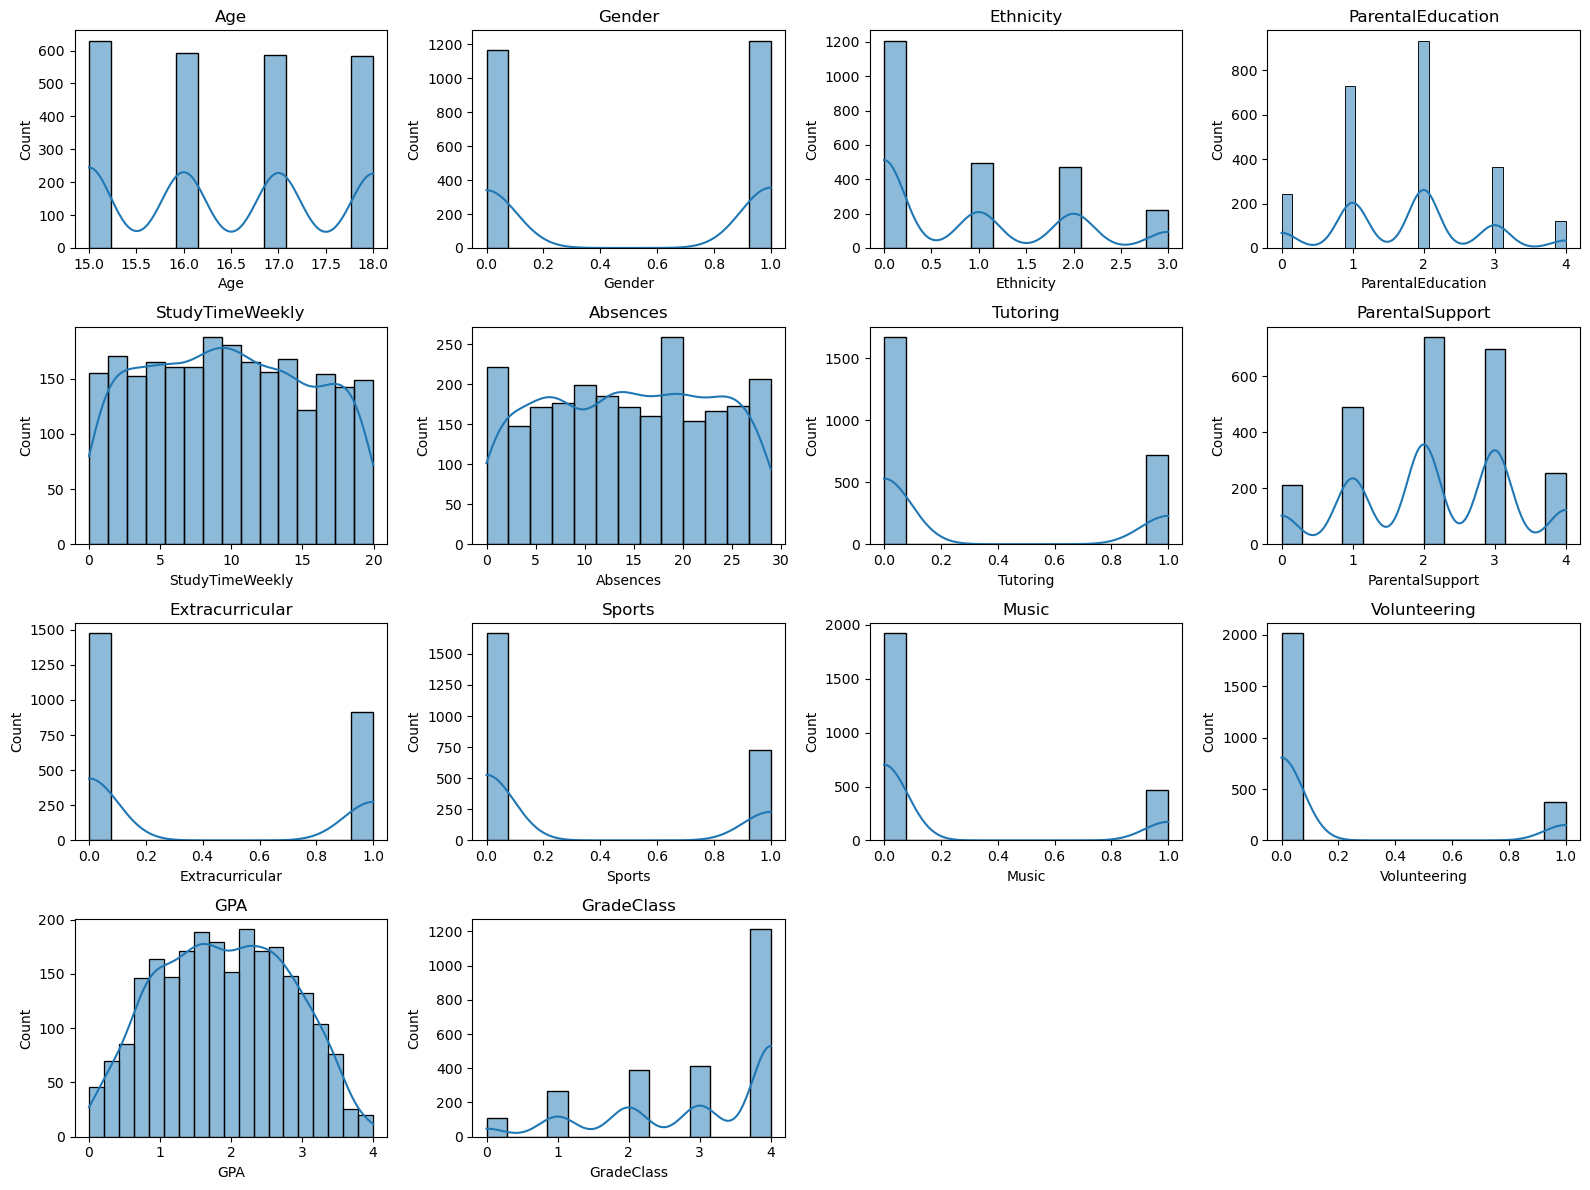

In [15]:
num_cols = [
    'Age','Gender','Ethnicity','ParentalEducation',
    'StudyTimeWeekly','Absences','Tutoring','ParentalSupport',
    'Extracurricular','Sports','Music','Volunteering',
    'GPA','GradeClass'
]

plt.figure(figsize=(16,12))

for i, col in enumerate(num_cols, 1):
    plt.subplot(4,4,i)
    sns.histplot(df[col], kde=True)
    plt.title(col)

plt.tight_layout()
plt.show()

              Feature       F_score       p_value Decision
5            Absences  13043.040639  0.000000e+00     Keep
12         GradeClass   3783.021023  0.000000e+00     Keep
7     ParentalSupport     90.268415  4.864766e-21     Keep
4     StudyTimeWeekly     79.364310  1.000201e-18     Keep
6            Tutoring     51.414981  9.923854e-13     Keep
8     Extracurricular     21.342139  4.045914e-06     Keep
10              Music     12.916947  3.322056e-04     Keep
9              Sports      8.027815  4.645076e-03     Keep
3   ParentalEducation      3.076260  7.957118e-02     Drop
2           Ethnicity      1.843141  1.747114e-01     Drop
1              Gender      0.426665  5.136929e-01     Drop
11       Volunteering      0.025368  8.734676e-01     Drop
0                 Age      0.000181  9.892595e-01     Drop


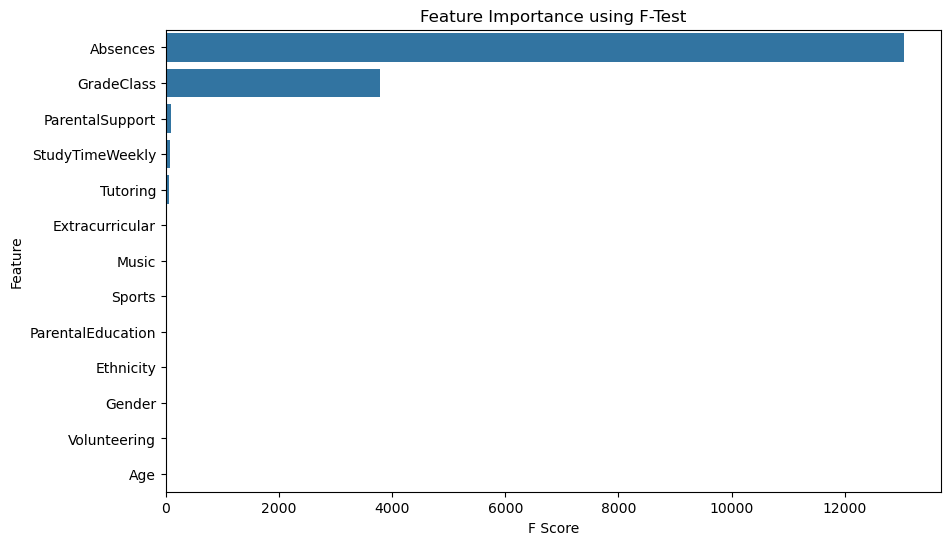


Selected Features: ['Absences', 'GradeClass', 'ParentalSupport', 'StudyTimeWeekly', 'Tutoring', 'Extracurricular', 'Music', 'Sports']

Shape of new dataset: (2392, 9)


In [17]:
# ===============================
# Import Libraries
# ===============================
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_selection import f_regression


# ===============================
# Define Features and Target
# ===============================
X = df.drop(['StudentID','GPA'], axis=1)
y = df['GPA']


# ===============================
# Perform F-Test for Regression
# ===============================
f_scores, p_values = f_regression(X, y)


# ===============================
# Create Results DataFrame
# ===============================
anova_results = pd.DataFrame({
    'Feature': X.columns,
    'F_score': f_scores,
    'p_value': p_values
})


# ===============================
# Sort by Importance
# ===============================
anova_results = anova_results.sort_values(by='F_score', ascending=False)


# ===============================
# Decide which features to keep
# ===============================
anova_results['Decision'] = anova_results['p_value'].apply(
    lambda x: 'Keep' if x < 0.05 else 'Drop'
)


# ===============================
# Print Results
# ===============================
print(anova_results)


# ===============================
# Plot Feature Importance
# ===============================
plt.figure(figsize=(10,6))

sns.barplot(
    data=anova_results,
    x='F_score',
    y='Feature'
)

plt.title("Feature Importance using F-Test")
plt.xlabel("F Score")
plt.ylabel("Feature")

plt.show()


# ===============================
# Select Important Features
# ===============================
selected_features = anova_results[
    anova_results['Decision'] == 'Keep'
]['Feature'].tolist()

print("\nSelected Features:", selected_features)


# ===============================
# Create New Dataset
# ===============================
df_selected = df[selected_features + ['GPA']]

print("\nShape of new dataset:", df_selected.shape)

In [19]:
df_selected.head()

,Absences,GradeClass,ParentalSupport,StudyTimeWeekly,Tutoring,Extracurricular,Music,Sports,GPA
0,7,2.0,2,19.833723,1,0,1,0,2.929196
1,0,1.0,1,15.408756,0,0,0,0,3.042915
2,26,4.0,2,4.210570,0,0,0,0,0.112602
3,14,3.0,3,10.028829,0,1,0,0,2.054218
4,17,4.0,3,4.672495,1,0,0,0,1.288061


In [21]:
from sklearn.preprocessing import StandardScaler
scaler =StandardScaler() 
col =['Absences', 'GradeClass', 'ParentalSupport', 'StudyTimeWeekly', 'Tutoring', 'Extracurricular', 'Music', 'Sports']
df_selected[col] =scaler.fit_transform(df_selected[col])

In [23]:
df_selected.head()

,Absences,GradeClass,ParentalSupport,StudyTimeWeekly,Tutoring,Extracurricular,Music,Sports,GPA
0,-0.890822,-0.797387,-0.108744,1.780336,1.522371,-0.788476,2.019544,-0.660132,2.929196
1,-1.717694,-1.607990,-0.999551,0.997376,-0.656870,-0.788476,-0.495161,-0.660132,3.042915
2,1.353542,0.823819,-0.108744,-0.984045,-0.656870,-0.788476,-0.495161,-0.660132,0.112602
3,-0.063951,0.013216,0.782063,0.045445,-0.656870,1.268269,-0.495161,-0.660132,2.054218
4,0.290422,0.823819,0.782063,-0.902311,1.522371,-0.788476,-0.495161,-0.660132,1.288061


In [25]:
X =df_selected.drop('GPA',axis=1)
y =df_selected['GPA']

In [27]:
from sklearn.model_selection import train_test_split

In [29]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [31]:
from sklearn.neighbors import KNeighborsClassifier

In [65]:
from sklearn.neighbors import KNeighborsRegressor

model = KNeighborsRegressor(n_neighbors=7)

model.fit(X_train, y_train)

KNeighborsRegressor(n_neighbors=7)

In [67]:
y_pred = model.predict(X_test)

In [69]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", mean_squared_error(y_test, y_pred, squared=False))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 0.20830519691080693
MSE: 0.07934926911885358
RMSE: 0.2816900231084757
R2 Score: 0.9040438510073826
